In [ ]:
!gdown 1wNAlV8GCMWly8sCutQynPl14K216MMOA
!gdown 1ynww2cJxUntqo06seH6n89-ny45mpWCl
!unzip -a "/content/application_test.csv.zip"
!unzip -a "/content/application_train.csv.zip"

Downloading...
From: https://drive.google.com/uc?id=1wNAlV8GCMWly8sCutQynPl14K216MMOA
To: /content/application_test.csv.zip
100% 6.09M/6.09M [00:00<00:00, 30.8MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1ynww2cJxUntqo06seH6n89-ny45mpWCl
From (redirected): https://drive.google.com/uc?id=1ynww2cJxUntqo06seH6n89-ny45mpWCl&confirm=t&uuid=bccb2658-4fad-4df7-bae6-569234250d22
To: /content/application_train.csv.zip
100% 37.8M/37.8M [00:01<00:00, 24.5MB/s]
Archive:  /content/application_test.csv.zip
  inflating: application_test.csv    [binary]
Archive:  /content/application_train.csv.zip
  inflating: application_train.csv   [binary]


## Перезаписать train

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
train_path = "/content/application_train.csv"
test_path = "/content/application_test.csv"
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [ ]:
select_columns = [
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    "NAME_EDUCATION_TYPE",
    "NAME_HOUSING_TYPE",
    "OWN_CAR_AGE",
    "LIVINGAREA_AVG",
    "TARGET",

]
train = train[select_columns]

In [ ]:
train.FLAG_OWN_CAR = np.where(train.FLAG_OWN_CAR == "Y", 1, 0)
train.FLAG_OWN_REALTY = np.where(train.FLAG_OWN_REALTY == "Y", 1, 0)
train.LIVINGAREA_AVG = train.LIVINGAREA_AVG * 100 # Признак изначально нормирован, чтобы расширить шкалу умножаю

## Описательная статистика

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   FLAG_OWN_CAR         307511 non-null  int64  
 1   FLAG_OWN_REALTY      307511 non-null  int64  
 2   DAYS_EMPLOYED        307511 non-null  int64  
 3   AMT_INCOME_TOTAL     307511 non-null  float64
 4   AMT_CREDIT           307511 non-null  float64
 5   AMT_ANNUITY          307499 non-null  float64
 6   AMT_GOODS_PRICE      307233 non-null  float64
 7   CNT_CHILDREN         307511 non-null  int64  
 8   NAME_EDUCATION_TYPE  307511 non-null  object 
 9   NAME_HOUSING_TYPE    307511 non-null  object 
 10  OWN_CAR_AGE          104582 non-null  float64
 11  LIVINGAREA_AVG       153161 non-null  float64
 12  TARGET               307511 non-null  int64  
dtypes: float64(6), int64(5), object(2)
memory usage: 30.5+ MB


None

,count,mean,std,min,25%,50%,75%,max
FLAG_OWN_CAR,307511.0,0.340,0.474,0.0,0.00,0.00,1.00,1.0
FLAG_OWN_REALTY,307511.0,0.694,0.461,0.0,0.00,1.00,1.00,1.0
DAYS_EMPLOYED,307511.0,63815.046,141275.767,-17912.0,-2760.00,-1213.00,-289.00,365243.0
AMT_INCOME_TOTAL,307511.0,168797.919,237123.146,25650.0,112500.00,147150.00,202500.00,117000000.0
AMT_CREDIT,307511.0,599026.000,402490.777,45000.0,270000.00,513531.00,808650.00,4050000.0
AMT_ANNUITY,307499.0,27108.574,14493.737,1615.5,16524.00,24903.00,34596.00,258025.5
AMT_GOODS_PRICE,307233.0,538396.207,369446.461,40500.0,238500.00,450000.00,679500.00,4050000.0
CNT_CHILDREN,307511.0,0.417,0.722,0.0,0.00,0.00,1.00,19.0
OWN_CAR_AGE,104582.0,12.061,11.945,0.0,5.00,9.00,15.00,91.0
LIVINGAREA_AVG,153161.0,10.740,11.056,0.0,4.53,7.45,12.99,100.0


,FLAG_OWN_CAR,FLAG_OWN_REALTY,DAYS_EMPLOYED,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_CHILDREN,NAME_EDUCATION_TYPE,NAME_HOUSING_TYPE,OWN_CAR_AGE,LIVINGAREA_AVG,TARGET
102587,1,1,-2093,270000.0,1223010.0,48631.5,1125000.0,0,Higher education,House / apartment,4.0,NaN,0
115169,0,0,365243,99000.0,253737.0,15520.5,229500.0,0,Secondary / secondary special,House / apartment,NaN,3.59,0
82879,0,1,365243,157500.0,350181.0,34245.0,328500.0,0,Secondary / secondary special,House / apartment,NaN,2.41,0


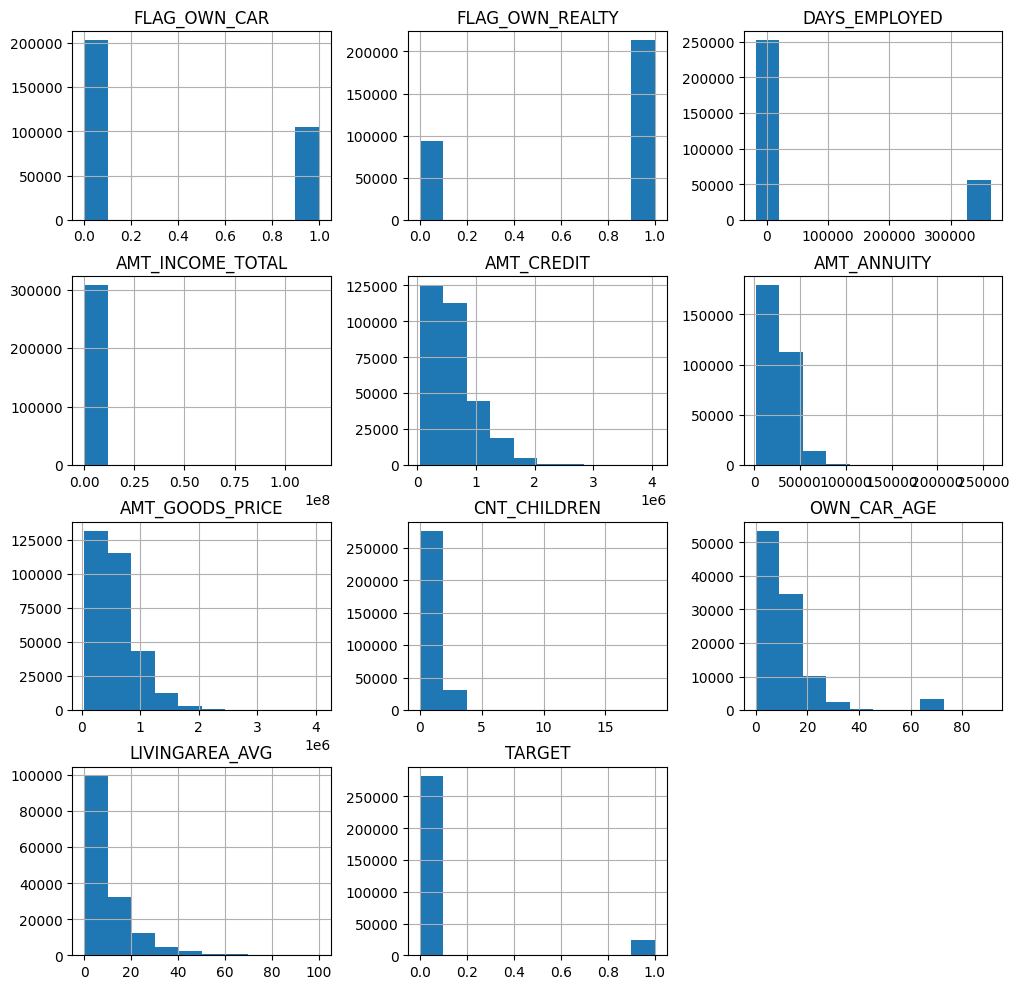

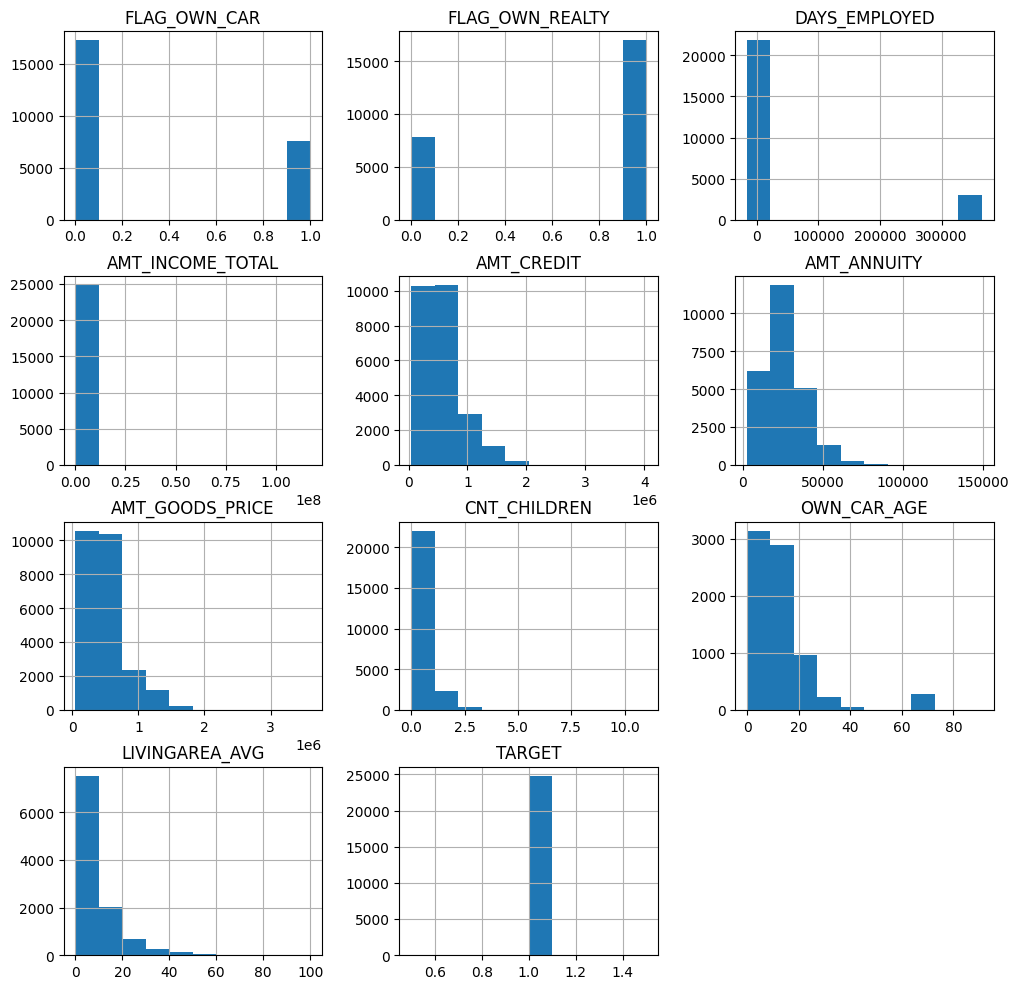

In [ ]:
display(train.info())
print("=" * 100)
display(train.describe().round(3).T)
print("=" * 100)
display(train.sample(3))
print("=" * 100)
train.hist(figsize=(12, 12))
plt.show()
print("=" * 100)
train[train.TARGET == 1].hist(figsize=(12, 12))
plt.show()

### Визуализация данных

In [ ]:
from scipy.stats import gaussian_kde

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

In [ ]:
# @title
def draw_distr(x: pd.Series, title, bins=30):
  fig = make_subplots(rows=1, cols=3, column_titles=["Box-Plot", "Histogram", "PDF"])
  fig.add_trace(
      go.Box(
          y=x,
          name="",
          boxpoints="outliers"
      ),
      row=1, col=1
  )
  fig.add_trace(
      go.Histogram(
          x=x,
          name=title,
          nbinsx=bins,
        ),
      row=1, col=2
  )

  density = gaussian_kde(x)
  x_vals = np.linspace(x.min(), x.max(), 100)
  y_vals = density(x_vals)

  fig.add_trace(
      go.Scatter(
          x=x_vals,
          y=y_vals,
          fill='tozeroy',
          name=title,
        ),
      row=1, col=3
  )
  fig.add_annotation(
    y=1.3,
    x=1,
    xref="paper",
    yref="paper",

    text=f"\nμ = {x.mean():.2f} | σ = {x.std():.2f}<br>skew = {x.skew():.2f} | kurtos = {x.kurtosis():.2f}",
    bordercolor="black",
    showarrow=False,
    font=dict(size=18)
    )
  fig.update_layout(height=450, width=1200, showlegend=False, title_text=title, title_font_size=26, title_x=0.5,)
  fig.show()

In [ ]:
# @title
show_columns = [
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    #"NAME_EDUCATION_TYPE",
    #"NAME_HOUSING_TYPE",
    "OWN_CAR_AGE",
    "LIVINGAREA_AVG",
    "TARGET",

]
for col in show_columns:
  draw_distr(train[col].dropna(), col)

Output hidden; open in https://colab.research.google.com to view.

## Первоначальное обучение - отправная точка

In [ ]:
train = pd.concat([train.drop("NAME_EDUCATION_TYPE", axis=1), pd.get_dummies(train.NAME_EDUCATION_TYPE)], axis=1)
train = pd.concat([train.drop("NAME_HOUSING_TYPE", axis=1), pd.get_dummies(train.NAME_HOUSING_TYPE)], axis=1)
train

,FLAG_OWN_CAR,FLAG_OWN_REALTY,DAYS_EMPLOYED,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_CHILDREN,OWN_CAR_AGE,LIVINGAREA_AVG,...,Higher education,Incomplete higher,Lower secondary,Secondary / secondary special,Co-op apartment,House / apartment,Municipal apartment,Office apartment,Rented apartment,With parents
0,0,1,-637,202500.0,406597.5,24700.5,351000.0,0,NaN,1.90,...,False,False,False,True,False,True,False,False,False,False
1,0,0,-1188,270000.0,1293502.5,35698.5,1129500.0,0,NaN,5.49,...,True,False,False,False,False,True,False,False,False,False
2,1,1,-225,67500.0,135000.0,6750.0,135000.0,0,26.0,NaN,...,False,False,False,True,False,True,False,False,False,False
3,0,1,-3039,135000.0,312682.5,29686.5,297000.0,0,NaN,NaN,...,False,False,False,True,False,True,False,False,False,False
4,0,1,-3038,121500.0,513000.0,21865.5,513000.0,0,NaN,NaN,...,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,0,-236,157500.0,254700.0,27558.0,225000.0,0,NaN,19.65,...,False,False,False,True,False,False,False,False,False,True
307507,0,1,365243,72000.0,269550.0,12001.5,225000.0,0,NaN,2.57,...,False,False,False,True,False,True,False,False,False,False
307508,0,1,-7921,153000.0,677664.0,29979.0,585000.0,0,NaN,92.79,...,True,False,False,False,False,True,False,False,False,False
307509,0,1,-4786,171000.0,370107.0,20205.0,319500.0,0,NaN,0.61,...,False,False,False,True,False,True,False,False,False,False


In [ ]:
data = train.dropna()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# @title
def f1_th(y_true, y_proba, show=True):
  th = np.arange(0, 1, 0.01)
  scores = []
  m = (0, 0) # score / thrs
  for t in th:
    scores.append(f1_score(y_true, (y_proba > t).astype(np.int64)))
    m = max(m, (scores[-1], t))
  if show:
    fig = px.line(
        x=th,
        y=scores,
        markers=True
    )
    fig.update_layout(
      title=f'F1 от порога определения класса',
      xaxis_title='Threshold',
      yaxis_title='F1-Score',
      height=600,
        width=600
    )
    fig.show()
  print(f"Порог классификации {m[1]:.2f}")
  return (y_proba > m[1]).astype(np.int64)

In [ ]:
continuous_cols = [
    #"FLAG_OWN_CAR",
    #"FLAG_OWN_REALTY",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    #"NAME_EDUCATION_TYPE",
    #"NAME_HOUSING_TYPE",
    "OWN_CAR_AGE",
    "LIVINGAREA_AVG",
    #"TARGET",

]
scaler = StandardScaler()
X, y = data.drop("TARGET", axis=1), data.TARGET
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols]) Не скалирую чтобы roc-auc было меньше, и увеличить разность между изнчальным и после обработки
#X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

In [ ]:
prob = model.predict_proba(X_test)
y_pred = f1_th(y_test, prob[:, 1])

Порог классификации 0.08


In [ ]:
print(classification_report(y_test, y_pred))
print(f"ROC_AUC: {roc_auc_score(y_test, y_pred)}")

              precision    recall  f1-score   support

           0       0.95      0.59      0.73      9320
           1       0.08      0.52      0.14       617

    accuracy                           0.59      9937
   macro avg       0.51      0.56      0.43      9937
weighted avg       0.90      0.59      0.69      9937

ROC_AUC: 0.5572383156767134


## Обработка пропусков

In [ ]:
# @title
def draw_null():
  null = train.isna().sum()
  display(null[null.values > 0].reset_index().T)

  fig = px.histogram(
      null,
      x=train.columns,
      y=null.values
  )
  fig.update_layout(height=400, width=600, title=f'Пропуски в данных',title_font_size=26, title_x=0.5,)
  fig.show()

In [ ]:
draw_null()

,0,1,2,3
index,AMT_ANNUITY,AMT_GOODS_PRICE,OWN_CAR_AGE,LIVINGAREA_AVG
0,12,278,202929,154350


In [ ]:
# @title
def sample_same_distribution(data, n_samples=None, random_state=None):
    """
    Семплирует данные из распределения, похожего на исходное.
    Работает хорошо для правосторонне асимметричных данных (логнормальные-like).

    Parameters
    ----------
    data : array-like
        Вектор исходных наблюдений.
    n_samples : int
        Сколько семплов нужно получить (если None — столько же, сколько в data).
    random_state : int
        Для воспроизводимости.

    Returns
    -------
    np.ndarray : семплированные данные
    """
    rng = np.random.default_rng(random_state)
    data = np.asarray(data)

    # Чтобы избежать проблем с нулями → добавляем маленькое число
    eps = 1e-9
    log_data = np.log(data + eps)

    # Оценка параметров логнормального распределения
    mu = np.mean(log_data)
    sigma = np.std(log_data)

    if n_samples is None:
        n_samples = len(data)

    # Семплирование в лог-пространстве
    sampled_log = rng.normal(mu, sigma, size=n_samples)

    # Обратная трансформация
    sampled = np.exp(sampled_log) - eps

    return sampled

In [ ]:
# @title
def sample_same_distribution_truncated(data, n_samples=None, random_state=None,
                                       max_quantile=0.999):

    rng = np.random.default_rng(random_state)
    data = np.asarray(data)

    eps = 1e-9
    log_data = np.log(data + eps)

    mu = log_data.mean()
    sigma = log_data.std()

    if n_samples is None:
        n_samples = len(data)

    oversample = int(n_samples * 3)

    sampled_log = rng.normal(mu, sigma, size=oversample)
    sampled = np.exp(sampled_log) - eps

    max_allowed = np.quantile(data, max_quantile)
    sampled = sampled[sampled <= max_allowed]

    if len(sampled) < n_samples:
        extra = sample_same_distribution_truncated(
            data,
            n_samples - len(sampled),
            random_state,
            max_quantile
        )
        sampled = np.concatenate([sampled, extra])

    return sampled[:n_samples]

In [ ]:
#train = train.drop("OWN_CAR_AGE", axis=1)
#train = train.drop("LIVINGAREA_AVG", axis=1)
#train.OWN_CAR_AGE = train.OWN_CAR_AGE.fillna(train.OWN_CAR_AGE.median())
#train.LIVINGAREA_AVG = train.LIVINGAREA_AVG.fillna(train.LIVINGAREA_AVG.median())
train.loc[train.OWN_CAR_AGE.isna(), "OWN_CAR_AGE"] = sample_same_distribution_truncated(train.OWN_CAR_AGE.dropna(), train.OWN_CAR_AGE.isna().sum()).astype(np.int64)
train.loc[train.LIVINGAREA_AVG.isna(), "LIVINGAREA_AVG"] = sample_same_distribution_truncated(train.LIVINGAREA_AVG.dropna(), train.LIVINGAREA_AVG.isna().sum())
train.AMT_ANNUITY = train.AMT_ANNUITY.fillna(train.AMT_ANNUITY.median())
train.AMT_GOODS_PRICE = train.AMT_GOODS_PRICE.fillna(train.AMT_GOODS_PRICE.median())

In [ ]:
draw_distr(train.LIVINGAREA_AVG, "LIVINGAREA_AVG")
draw_distr(train.OWN_CAR_AGE, "OWN_CAR_AGE")


Output hidden; open in https://colab.research.google.com to view.

## Обнаружение и устранение отклонений

In [ ]:
# @title
def IQR_clean(x: pd.Series, r=False):
  Q1 = x.quantile(0.25)
  Q3 = x.quantile(0.75)
  IQR = Q3 - Q1
  upper_thrs = Q3 + 1.5 * IQR
  lower_thrs = Q1 - 1.5 * IQR

  filter = x.loc[(x < lower_thrs) | (x > upper_thrs)]
  print(f'Выбросы в признаке {x.name}: {filter.shape}, {(100 * filter.shape[0] / x.shape[0]):.1f} %')
  print(f'Остаток: {x.shape[0] - filter.shape[0]}')
  if r:
    return (x < lower_thrs) | (x > upper_thrs)
  else:
    print("НЕ удалено")

In [ ]:
# @title
def draw_clear_dist(x, title, bins=20):
  fig = make_subplots(rows=1, cols=4, column_titles=[ "Default", "LOG", "SQRT", "IQR"])
  fig.add_trace(
      go.Histogram(
          x=x,
          name=title,
          nbinsx=bins,
        ),
      row=1, col=1
  )
  fig.add_trace(
      go.Histogram(
          x=np.log(x + 1),
          name=title,
          nbinsx=bins,
        ),
      row=1, col=2
  )
  fig.add_trace(
      go.Histogram(
          x=np.sqrt(x),
          name=title,
          nbinsx=bins,
        ),
      row=1, col=3
  )
  fig.add_trace(
      go.Histogram(
          x=x[np.logical_not(IQR_clean(x, True))],
          name=title,
          nbinsx=bins,
        ),
      row=1, col=4
  )
  fig.update_layout(height=400, width=1000, showlegend=False, title_text=title, title_font_size=26, title_x=0.5,)
  fig.show()

DAYS_EMPLOYED

Стоит заглушка, пока не понятно что с этим делать, поэтому просто удалим и поменяем знак

In [ ]:
train.DAYS_EMPLOYED = np.abs(train.DAYS_EMPLOYED)

In [ ]:
display(train[train.DAYS_EMPLOYED == 365243])
train = train.drop(index=train[train.DAYS_EMPLOYED == 365243].index)
#train.loc[train.DAYS_EMPLOYED == 365243, "DAYS_EMPLOYED"] = 0

,FLAG_OWN_CAR,FLAG_OWN_REALTY,DAYS_EMPLOYED,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_CHILDREN,OWN_CAR_AGE,LIVINGAREA_AVG,...,Higher education,Incomplete higher,Lower secondary,Secondary / secondary special,Co-op apartment,House / apartment,Municipal apartment,Office apartment,Rented apartment,With parents
8,0,1,365243,112500.000,1019610.0,33826.5,913500.0,0,0.0,3.713069,...,False,False,False,True,False,True,False,False,False,False
11,0,1,365243,38419.155,148365.0,10678.5,135000.0,0,0.0,12.965524,...,False,False,False,True,False,True,False,False,False,False
23,0,1,365243,83250.000,239850.0,23850.0,225000.0,0,5.0,14.840000,...,False,False,False,True,False,True,False,False,False,False
38,0,1,365243,99000.000,247275.0,17338.5,225000.0,0,14.0,9.220000,...,False,False,False,True,False,True,False,False,False,False
43,0,1,365243,108000.000,746280.0,42970.5,675000.0,0,0.0,21.130000,...,True,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307469,0,1,365243,202500.000,703728.0,29943.0,607500.0,0,5.0,2.130000,...,False,False,False,True,False,True,False,False,False,False
307483,0,1,365243,99000.000,247275.0,16479.0,225000.0,0,15.0,0.760000,...,False,False,False,True,False,True,False,False,False,False
307487,0,1,365243,117000.000,1071909.0,31473.0,936000.0,0,0.0,8.634925,...,False,False,False,True,False,True,False,False,False,False
307505,0,1,365243,112500.000,225000.0,22050.0,225000.0,0,2.0,23.020000,...,False,False,False,True,False,True,False,False,False,False


In [ ]:
draw_distr(train.DAYS_EMPLOYED, train.DAYS_EMPLOYED.name)

### Визуализация

In [ ]:
fix_columns = [
    #"FLAG_OWN_CAR",
    #"FLAG_OWN_REALTY",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    #"NAME_EDUCATION_TYPE",
    #"NAME_HOUSING_TYPE",
    "OWN_CAR_AGE",
    "LIVINGAREA_AVG",
    #"TARGET",

]
for c in fix_columns:
  draw_clear_dist(train[c], c)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import seaborn as sns

In [ ]:
pair_col = [
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    #"NAME_EDUCATION_TYPE",
    #"NAME_HOUSING_TYPE",
    #"OWN_CAR_AGE",
    #"LIVINGAREA_AVG",
    "TARGET",
]
pairs = train[pair_col].sample(10000)

In [ ]:
fig = px.scatter_matrix(pairs, color="TARGET")
fig.update_layout(
    width=1000,
    height=1000,
    hovermode='closest')
fig.show()

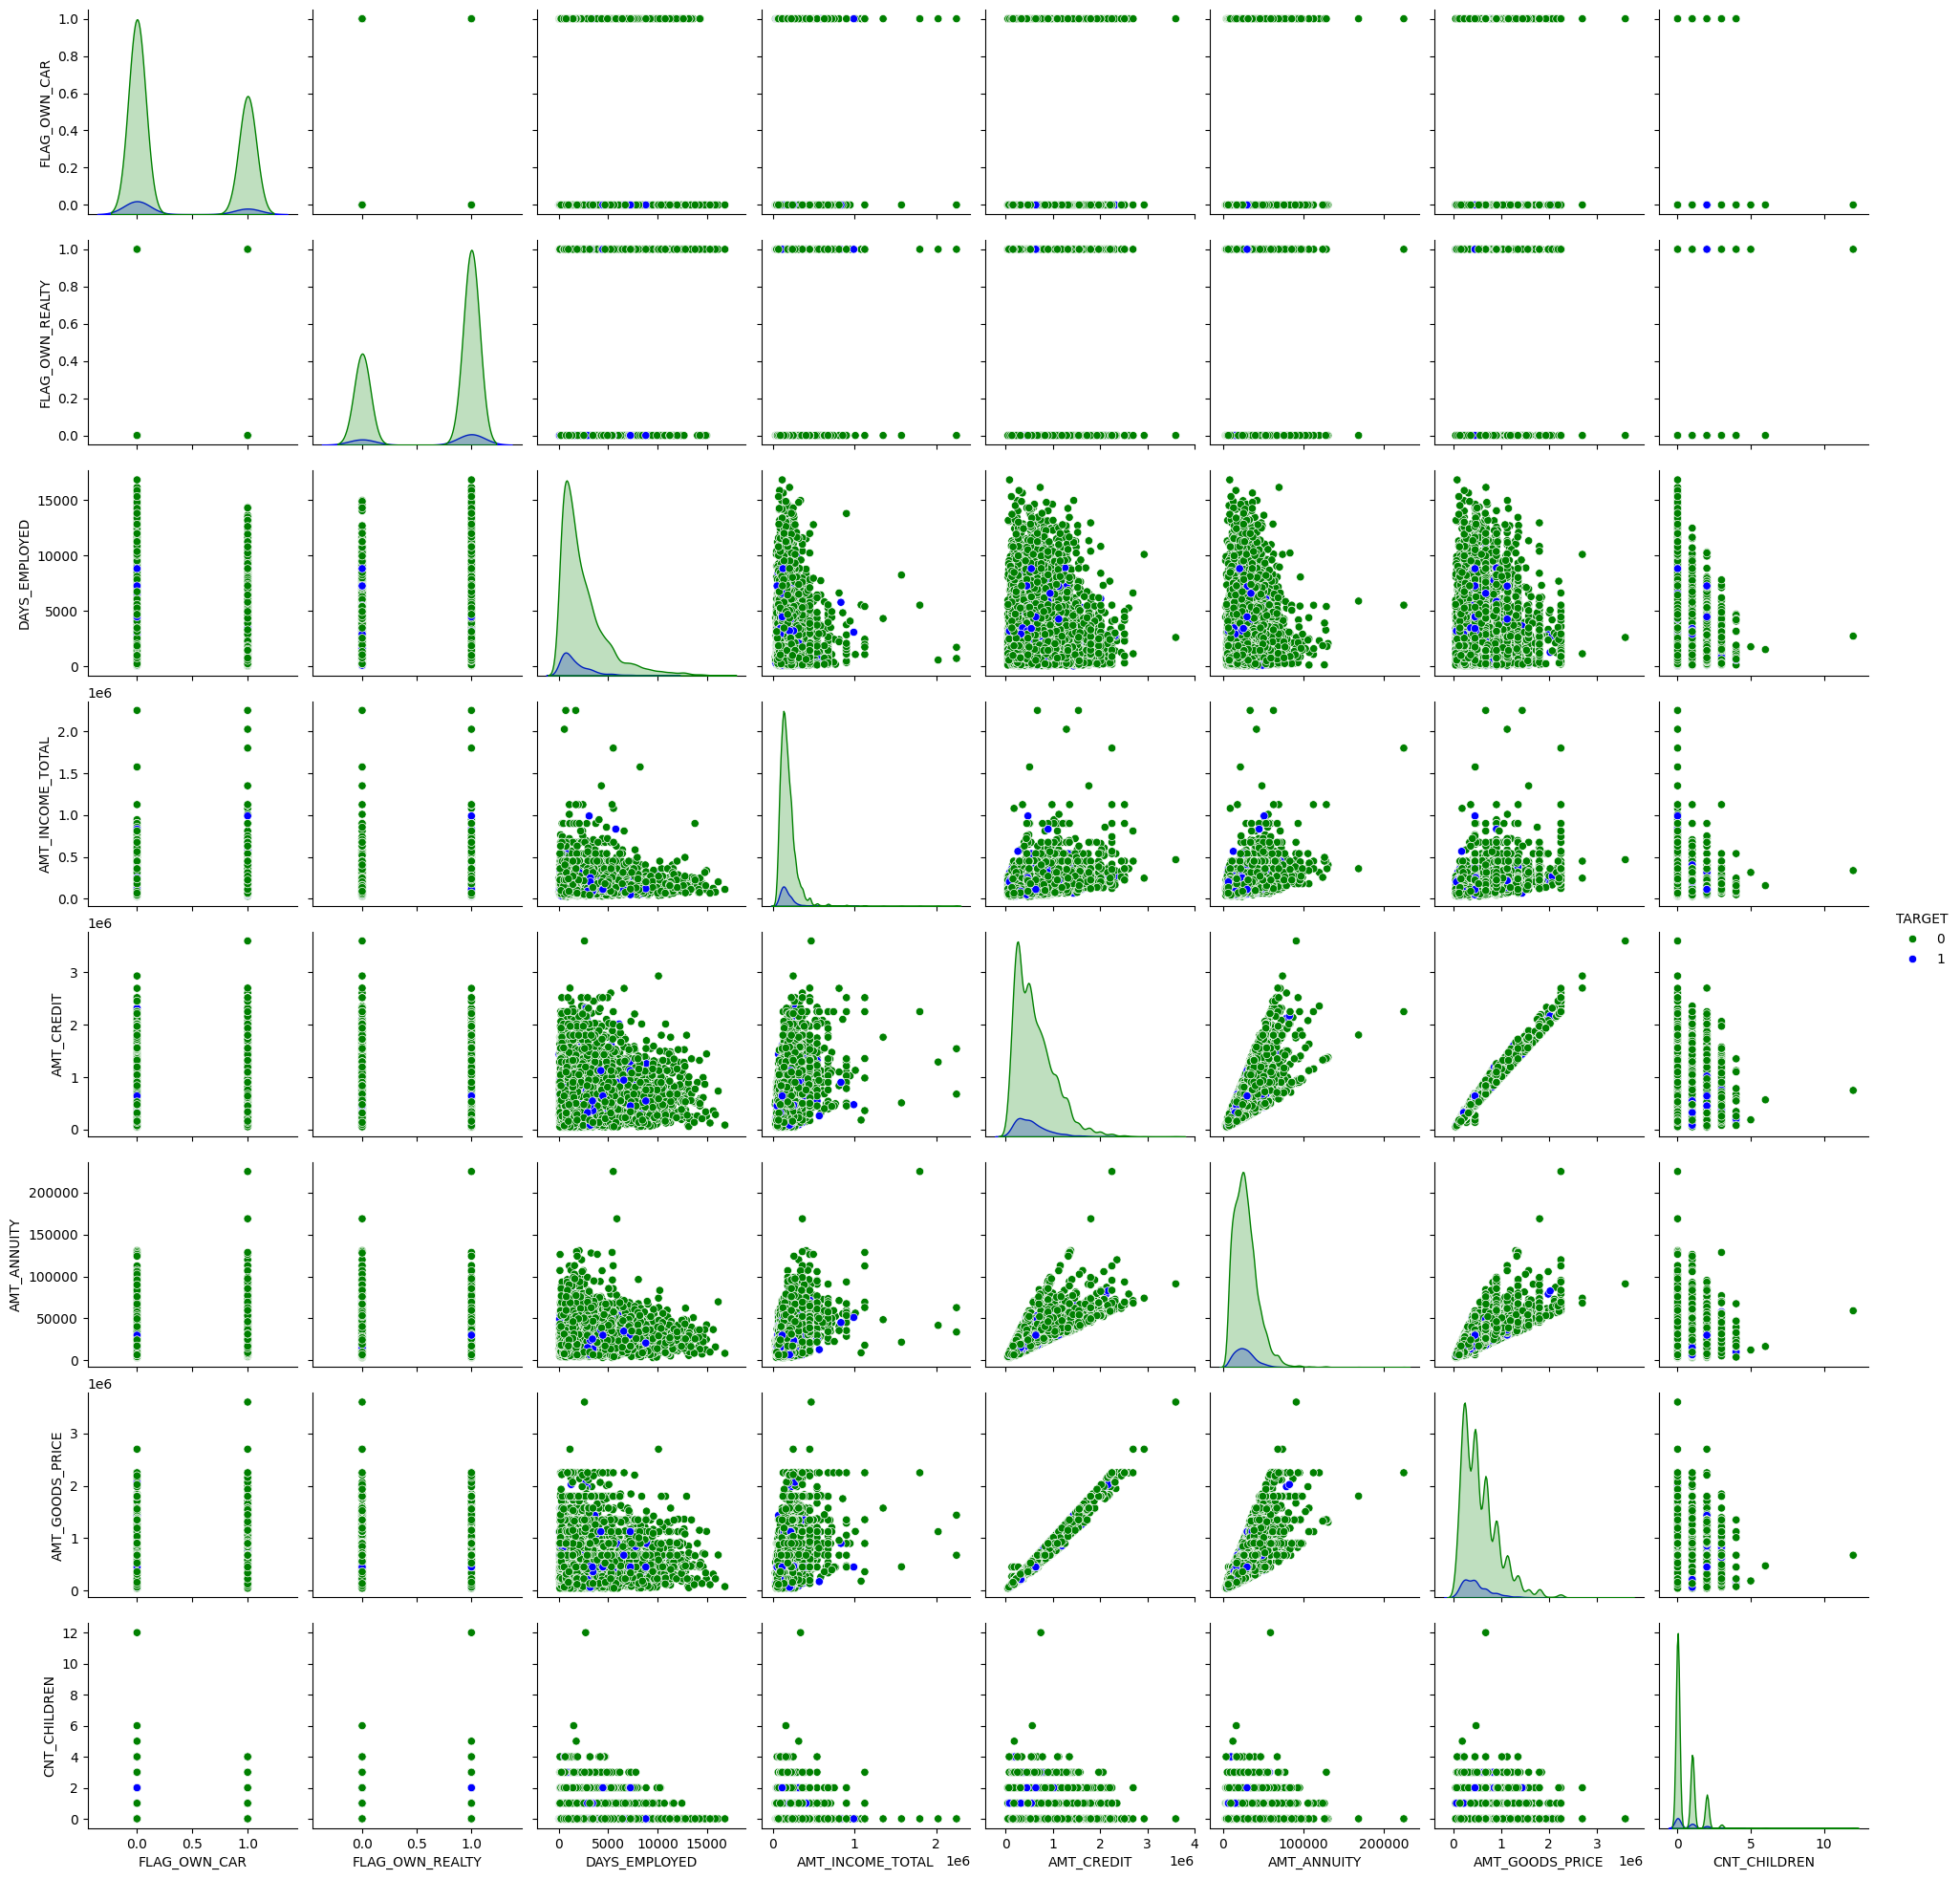

In [ ]:
ax = sns.pairplot(pairs, hue="TARGET",palette=["g","b"])
plt.show()

### Преобразование
IQR чистим только AMT_INCOME_TOTAL и CNT CHILDREN, все остальное логарифмируем

In [ ]:
fix_columns = [
    #"FLAG_OWN_CAR",
    #"FLAG_OWN_REALTY",
    "DAYS_EMPLOYED",
    #"AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    #"CNT_CHILDREN",
    #"NAME_EDUCATION_TYPE",
    #"NAME_HOUSING_TYPE",
    "OWN_CAR_AGE",
    "LIVINGAREA_AVG",
    #"TARGET",

]
train = train.drop(index=train[IQR_clean(train.AMT_INCOME_TOTAL, True)].index)
train = train.drop(index=train[IQR_clean(train.CNT_CHILDREN, True)].index)
#train = train.drop(index=train[IQR_clean(train.DAYS_EMPLOYED, True)].index)
for c in fix_columns:
  train[c] = np.log(train[c] + 1)
  #train = train.drop(index=train[IQR_clean(train[c], True)].index)

Выбросы в признаке AMT_INCOME_TOTAL: (8752,), 3.5 %
Остаток: 243385
Выбросы в признаке CNT_CHILDREN: (3982,), 1.6 %
Остаток: 239403


In [ ]:
train.TARGET.value_counts()

,count
TARGET,
0,218495
1,20908


In [ ]:
train.to_csv("application.csv")

## Повторное обучение

In [ ]:
continuous_cols = [
    #"FLAG_OWN_CAR",
    #"FLAG_OWN_REALTY",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    #"NAME_EDUCATION_TYPE",
    #"NAME_HOUSING_TYPE",
    "OWN_CAR_AGE",
    "LIVINGAREA_AVG",
    #"TARGET",

]
data = train.copy()

In [ ]:
scaler = StandardScaler()
X, y = data.drop("TARGET", axis=1), data.TARGET
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
prob = model.predict_proba(X_test)
y_pred = f1_th(y_test, prob[:, 1], show=False)
print(classification_report(y_test, y_pred))
print(f"ROC_AUC: {roc_auc_score(y_test, prob[:, 1])}")

Порог классификации 0.11
              precision    recall  f1-score   support

           0       0.93      0.78      0.85     43744
           1       0.14      0.39      0.21      4137

    accuracy                           0.74     47881
   macro avg       0.54      0.58      0.53     47881
weighted avg       0.86      0.74      0.79     47881

ROC_AUC: 0.6335726595009724


# SMOTE семлирование
Синтетику добавляю только в train

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
data = train.copy()
smote = SMOTE(
    sampling_strategy="auto",
    random_state=42,
    k_neighbors=5,
)

In [ ]:
scaler = StandardScaler()
X, y = data.drop("TARGET", axis=1), data.TARGET
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

x_sint, y_sint = smote.fit_resample(X_train, y_train)

X_train = pd.concat([X_train, x_sint], ignore_index=True)
y_train = pd.concat([y_train, y_sint], ignore_index=True)

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])
y_train.value_counts()

,count
TARGET,
0,347236
1,190238


In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

In [ ]:
prob = model.predict_proba(X_test)
y_pred = f1_th(y_test, prob[:, 1], show=False)
print(classification_report(y_test, y_pred))
print(f"ROC_AUC: {roc_auc_score(y_test, prob[:, 1])}")

Порог классификации 0.39
              precision    recall  f1-score   support

           0       0.93      0.71      0.80     43418
           1       0.13      0.45      0.20      4142

    accuracy                           0.69     47560
   macro avg       0.53      0.58      0.50     47560
weighted avg       0.86      0.69      0.75     47560

ROC_AUC: 0.6155727734342358


# Баесовские сети и семплирование PGMPY

In [ ]:
!pip install -q pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 44.9 MB/s eta 0:00:00


In [ ]:
from pgmpy.estimators import HillClimbSearch, BayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork, BayesianNetwork, LinearGaussianBayesianNetwork, FunctionalBayesianNetwork
from pgmpy.sampling import BayesianModelSampling

from sklearn.preprocessing import KBinsDiscretizer

## Дискретизация и построение дискретной баесовской сети

In [ ]:
show_columns = [
    #"FLAG_OWN_CAR",
    #"FLAG_OWN_REALTY",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    #"NAME_EDUCATION_TYPE",
    #"NAME_HOUSING_TYPE",
    "OWN_CAR_AGE",
    "LIVINGAREA_AVG",
    #"TARGET",

]

disc = KBinsDiscretizer(
    n_bins=10,
    encode="ordinal",
    strategy="quantile"
)
data = train.copy()
data[continuous_cols] = disc.fit_transform(data[continuous_cols])
data = data.astype(np.int64)
data.head(3)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning:

Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning:

Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning:

Bins whose width are too small (i.e., <= 1e-8) in feature 6 are removed. Consider decreasing the number of bins.



,FLAG_OWN_CAR,FLAG_OWN_REALTY,DAYS_EMPLOYED,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_CHILDREN,OWN_CAR_AGE,LIVINGAREA_AVG,...,Higher education,Incomplete higher,Lower secondary,Secondary / secondary special,Co-op apartment,House / apartment,Municipal apartment,Office apartment,Rented apartment,With parents
0,0,1,2,6,3,4,3,0,0,1,...,0,0,0,1,0,1,0,0,0,0
1,0,0,3,8,9,7,9,0,0,3,...,1,0,0,0,0,1,0,0,0,0
2,1,1,0,0,0,0,0,0,7,9,...,0,0,0,1,0,1,0,0,0,0


ПОТЕРЯ ИНФОРМАЦИИ ПРИ ДИСКРЕТИЗАЦИИ, ПОЯВЛЯЕТСЯ МНОГО ДУБЛИКАТОВ

In [ ]:
display(data.duplicated().sum())
display(data.shape)

np.int64(8902)

(239403, 22)

In [ ]:
est = HillClimbSearch(data)
best_model = est.estimate(
    scoring_method="bdeu",
    #max_indegree=10,
    )
BN = DiscreteBayesianNetwork(best_model.edges())
BN.fit(data, estimator=BayesianEstimator, prior_type="BDeu")

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [ ]:
for cpd in BN.get_cpds():
  print(cpd)

+------------------+-----+---------------------+
| AMT_INCOME_TOTAL | ... | AMT_INCOME_TOTAL(8) |
+------------------+-----+---------------------+
| Higher education | ... | Higher education(1) |
+------------------+-----+---------------------+
| OWN_CAR_AGE      | ... | OWN_CAR_AGE(7)      |
+------------------+-----+---------------------+
| FLAG_OWN_CAR(0)  | ... | 0.69832911350647    |
+------------------+-----+---------------------+
| FLAG_OWN_CAR(1)  | ... | 0.3016708864935301  |
+------------------+-----+---------------------+
+-----------------+-----+---------------------+
| DAYS_EMPLOYED   | ... | DAYS_EMPLOYED(9)    |
+-----------------+-----+---------------------+
| FLAG_OWN_CAR    | ... | FLAG_OWN_CAR(1)     |
+-----------------+-----+---------------------+
| With parents    | ... | With parents(1)     |
+-----------------+-----+---------------------+
| CNT_CHILDREN(0) | ... | 0.5397790055248619  |
+-----------------+-----+---------------------+
| CNT_CHILDREN(1) | ... | 0.4

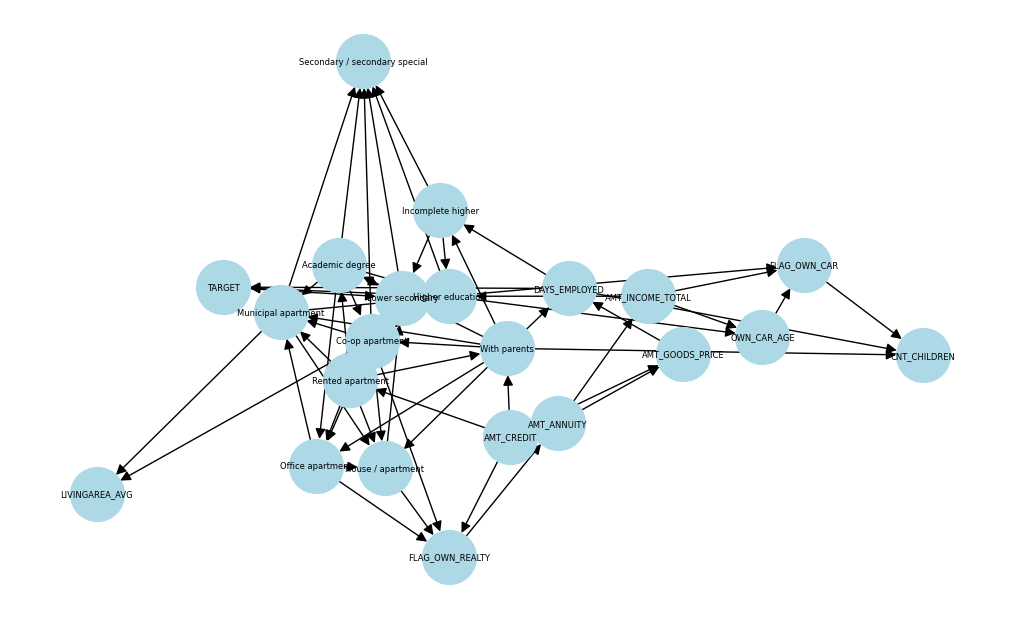

In [ ]:
import networkx as nx

plt.figure(figsize=(10, 6))

G = nx.DiGraph()

G.add_nodes_from(BN.nodes())
G.add_edges_from(BN.edges())

pos = nx.spring_layout(G, k=0.5, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1500,
    font_size=6,
    node_color="lightblue",
    arrowsize=15
)

plt.show()


In [ ]:
!pip install -q pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.4 MB/s eta 0:00:00


In [ ]:
from pyvis.network import Network

Функцию взял из своего НИР

In [ ]:
def graph_vizualization(G, node_font_size=10, edge_font_size=8):
    net = Network(notebook=False, height="100%", width="100%", bgcolor="#ffffff", directed=True)

    net.repulsion(node_distance=150, spring_length=200, spring_strength=0.15)
    net.force_atlas_2based(gravity=-50, central_gravity=0.01, spring_length=200)

    for node in G.nodes():
        net.add_node(node, label=str(node), title=str(node),
                    font={'size': node_font_size})

    for source, target, data in G.edges(data=True):
        if 'relation' in data:
            net.add_edge(source, target, label=data['relation'], title=data['relation'],
                        font={'size': edge_font_size})
        else:
            net.add_edge(source, target, font={'size': edge_font_size})

    net.toggle_physics(True)


    net.barnes_hut(gravity=-3000, central_gravity=0.3, spring_length=250)

    net.show("knowledge_graph.html", notebook=False)

In [ ]:
graph_vizualization(G)

knowledge_graph.html


## Семплирование

In [ ]:
from pgmpy.sampling import BayesianModelSampling

In [ ]:
sampler = BayesianModelSampling(BN)

"""synthetic_minority = sampler.likelihood_weighted_sample(evidence=[("TARGET", 1)], size=25000)

synthetic_minority = synthetic_minority.drop("_weight", axis=1)"""

synthetic_minority = sampler.forward_sample(size=500000)
synthetic_minority = synthetic_minority[synthetic_minority["TARGET"]==1]
synthetic_minority.shape

  0%|          | 0/22 [00:00<?, ?it/s]

(43948, 22)

In [ ]:
synthetic_minority

,FLAG_OWN_CAR,CNT_CHILDREN,FLAG_OWN_REALTY,AMT_ANNUITY,DAYS_EMPLOYED,TARGET,Incomplete higher,AMT_INCOME_TOTAL,Higher education,OWN_CAR_AGE,...,With parents,Rented apartment,Lower secondary,Academic degree,Secondary / secondary special,Co-op apartment,Municipal apartment,Office apartment,LIVINGAREA_AVG,House / apartment
0,0,0,1,7,0,1,0,3,0,2,...,0,0,0,0,1,0,0,0,8,1
7,1,1,1,2,2,1,0,0,0,2,...,0,0,0,0,1,0,0,0,0,1
13,1,0,1,3,5,1,0,8,0,3,...,0,0,0,0,1,0,0,0,6,1
51,1,0,1,7,6,1,0,6,0,5,...,0,1,0,0,1,0,0,0,3,0
63,1,0,1,0,3,1,0,5,1,5,...,0,0,0,0,0,0,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499950,0,0,1,0,4,1,0,2,0,0,...,0,0,0,0,1,0,0,0,8,1
499958,0,1,1,6,6,1,0,2,0,3,...,0,0,0,0,1,0,0,0,4,1
499978,0,1,0,2,7,1,0,1,0,0,...,0,1,0,0,1,0,0,0,4,0
499980,0,0,1,6,2,1,0,5,1,0,...,0,0,0,0,0,0,0,0,5,1


In [ ]:
show_columns = [
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    #"NAME_EDUCATION_TYPE",
    #"NAME_HOUSING_TYPE",
    "OWN_CAR_AGE",
    "LIVINGAREA_AVG",
    "TARGET",

]
corr = data[show_columns].corr()
fig = px.imshow(corr.round(3), text_auto=True)
fig.show()

Данные с синтетикой

In [ ]:
tmp = pd.concat([data, synthetic_minority], ignore_index=True)[show_columns].corr()
fig = px.imshow(tmp.round(3), text_auto=True)
fig.show()

In [ ]:
data = pd.concat([data, pd.get_dummies(data[continuous_cols].astype(np.str_))], axis=1)
data = data.drop(columns=continuous_cols).astype(np.int64)
data

,FLAG_OWN_CAR,FLAG_OWN_REALTY,TARGET,Academic degree,Higher education,Incomplete higher,Lower secondary,Secondary / secondary special,Co-op apartment,House / apartment,...,LIVINGAREA_AVG_0,LIVINGAREA_AVG_1,LIVINGAREA_AVG_2,LIVINGAREA_AVG_3,LIVINGAREA_AVG_4,LIVINGAREA_AVG_5,LIVINGAREA_AVG_6,LIVINGAREA_AVG_7,LIVINGAREA_AVG_8,LIVINGAREA_AVG_9
0,0,1,1,0,0,0,0,1,0,1,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
2,1,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,1
3,0,1,0,0,0,0,0,1,0,1,...,0,0,1,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307504,0,1,0,0,0,0,0,1,0,1,...,0,0,0,0,1,0,0,0,0,0
307506,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
307508,0,1,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
307509,0,1,1,0,0,0,0,1,0,1,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
synthetic_minority = pd.concat([synthetic_minority, pd.get_dummies(synthetic_minority[continuous_cols].astype(np.str_))], axis=1)
synthetic_minority = synthetic_minority.drop(columns=continuous_cols).astype(np.int64)
synthetic_minority

,FLAG_OWN_CAR,FLAG_OWN_REALTY,TARGET,Incomplete higher,Higher education,With parents,Rented apartment,Lower secondary,Academic degree,Secondary / secondary special,...,LIVINGAREA_AVG_0,LIVINGAREA_AVG_1,LIVINGAREA_AVG_2,LIVINGAREA_AVG_3,LIVINGAREA_AVG_4,LIVINGAREA_AVG_5,LIVINGAREA_AVG_6,LIVINGAREA_AVG_7,LIVINGAREA_AVG_8,LIVINGAREA_AVG_9
0,0,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
7,1,1,1,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
13,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
51,1,1,1,0,0,0,1,0,0,1,...,0,0,0,1,0,0,0,0,0,0
63,1,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499950,0,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
499958,0,1,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
499978,0,0,1,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
499980,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


## Визуализируем новые распределения - ТОЛЬКО ДЛЯ LABEL кодирования

In [ ]:
show_columns = [
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    #"NAME_EDUCATION_TYPE",
    #"NAME_HOUSING_TYPE",
    "OWN_CAR_AGE",
    "LIVINGAREA_AVG",
    "TARGET",

]
for col in show_columns:
  draw_distr(data[col], col)

## Обучение с данными баесовской сети
Синтетику добавляю только в train

In [ ]:
#scaler = StandardScaler()
X, y = data.drop("TARGET", axis=1), data.TARGET
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

X_train = pd.concat([X_train, synthetic_minority.drop("TARGET", axis=1)], ignore_index=True)
y_train = pd.concat([y_train, synthetic_minority.TARGET], ignore_index=True)

#X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
#X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [ ]:
X_train.shape

(235470, 82)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
prob = model.predict_proba(X_test)
y_pred = f1_th(y_test, prob[:, 1], show=False)
print(classification_report(y_test, y_pred))
print(f"ROC_AUC: {roc_auc_score(y_test, prob[:, 1])}")

Порог классификации 0.32
              precision    recall  f1-score   support

           0       0.93      0.77      0.85     43744
           1       0.14      0.39      0.21      4137

    accuracy                           0.74     47881
   macro avg       0.54      0.58      0.53     47881
weighted avg       0.86      0.74      0.79     47881

ROC_AUC: 0.6302241371513236


# Pomegranate

In [ ]:
!pip install -q git+https://github.com/jmschrei/pomegranate.git

  Preparing metadata (setup.py) ... done


In [ ]:
from pomegranate.bayesian_network import BayesianNetwork
from pomegranate.distributions import Categorical, Normal
import pomegranate

In [ ]:
pomegranate.__version__

'1.1.0'

In [ ]:
model = BayesianNetwork.from_samples(
    train.values,
    algorithm='exact',
    state_names=train.columns.tolist()
)

AttributeError: type object 'BayesianNetwork' has no attribute 'from_samples'

In [ ]:
BN.sample(100)

tensor([[-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -